In [8]:
!pip install pandas numpy matplotlib seaborn scikit-learn


mambajs 0.19.13

Process pip requirements ...

Requirement pandas already handled by conda/micromamba/mamba.
Requirement numpy already handled by conda/micromamba/mamba.
Requirement matplotlib already handled by conda/micromamba/mamba.
Requirement numpy already satisfied.
Requirement pandas already satisfied.
Requirement matplotlib already satisfied.
Requirement scikit-learn already handled by conda/micromamba/mamba.


In [11]:

# ==========================================
# FASE I: PREPARACIÓN Y ANÁLISIS DE DATOS (EDA)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

# 1. Carga de los datos
print("--- 1. CARGA DE DATOS ---")
df_completo = pd.read_csv("actas_cne_complete_report.csv")
df_inconsistencias = pd.read_csv("actas_inconsistencies_report.csv")

print("Total de actas:", df_completo.shape[0])
print("Actas con inconsistencias:", df_inconsistencias.shape[0])

# 2. Etiquetado de datos
actas_malas_ids = df_inconsistencias['Acta'].unique()

df_completo['es_inconsistente'] = df_completo['Acta Number'].isin(actas_malas_ids).astype(int)

# Ver información del dataset
print(df_completo.info())

--- 1. CARGA DE DATOS ---
Total de actas: 19137
Actas con inconsistencias: 2803
<class 'pandas.DataFrame'>
RangeIndex: 19137 entries, 0 to 19136
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Acta Number       19137 non-null  int64
 1   Departamento      19137 non-null  str  
 2   Municipio         19137 non-null  str  
 3   Centro            19137 non-null  str  
 4   DC                19137 non-null  int64
 5   LIBRE             19137 non-null  int64
 6   PINU              19137 non-null  int64
 7   PLH               19137 non-null  int64
 8   PNH               19137 non-null  int64
 9   PDF URL           19137 non-null  str  
 10  es_inconsistente  19137 non-null  int32
dtypes: int32(1), int64(6), str(4)
memory usage: 1.2 MB
None


--- 2. EXPLORACIÓN Y LIMPIEZA ---
Valores nulos encontrados en columnas de votos: 0


/tmp/xpython_42/3388036580.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_completo, x='es_inconsistente', palette=['#2ecc71', '#e74c3c'])


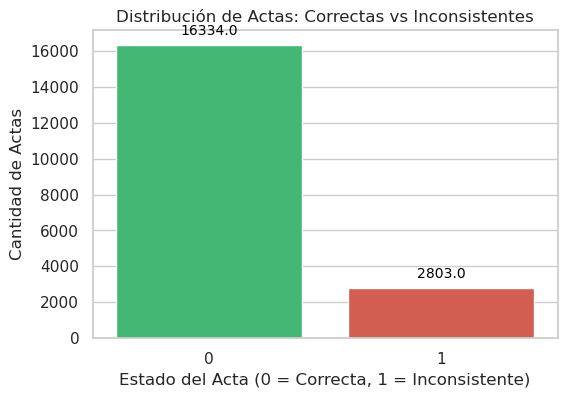

In [12]:
# 3. Exploración y Limpieza
print("--- 2. EXPLORACIÓN Y LIMPIEZA ---")
# Revisamos si hay valores nulos en los votos de los partidos
partidos = ['DC', 'LIBRE', 'PINU', 'PLH', 'PNH']
nulos_antes = df_completo[partidos].isnull().sum().sum()
print(f"Valores nulos encontrados en columnas de votos: {nulos_antes}")

# Imputación: Una casilla vacía en el acta significa 0 votos.
df_completo[partidos] = df_completo[partidos].fillna(0)

# Feature Engineering: Agregamos el Total de Votos.
# Esto ayuda al modelo a saber si la urna sobrepasó la carga electoral.
df_completo['Total_Votos'] = df_completo[partidos].sum(axis=1)

# 4. Visualización del Desbalance de Clases (¡Crucial para el reporte!)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_completo, x='es_inconsistente', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribución de Actas: Correctas vs Inconsistentes')
plt.xlabel('Estado del Acta (0 = Correcta, 1 = Inconsistente)')
plt.ylabel('Cantidad de Actas')

# Agregar los números sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

Generando Matriz de Correlación de Pearson...


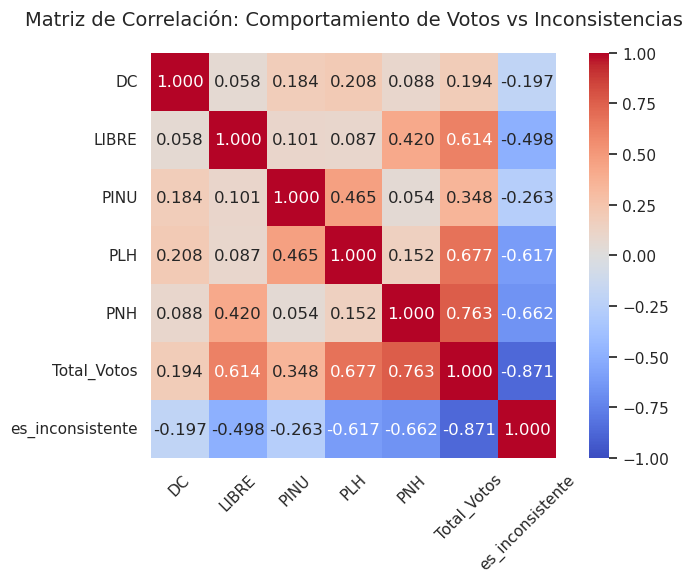


=== CORRELACIÓN DIRECTA CON LA INCONSISTENCIA ===
¿Qué variables aumentan cuando hay fraude/error?
DC            -0.196693
PINU          -0.262678
LIBRE         -0.497726
PLH           -0.616629
PNH           -0.662231
Total_Votos   -0.871452


In [13]:
print("Generando Matriz de Correlación de Pearson...")

# 1. Seleccionamos solo las columnas numéricas relevantes para nuestro análisis
columnas_analisis = partidos + ['Total_Votos', 'es_inconsistente']
df_correlacion = df_completo[columnas_analisis]

# 2. Calculamos la matriz matemática de correlación
matriz_corr = df_correlacion.corr()

# 3. Visualización mediante Mapa de Calor (Heatmap)
plt.figure(figsize=(8, 6))
# Usamos 'coolwarm' para ver claramente rojos (correlación positiva) y azules (negativa)
sns.heatmap(matriz_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)

plt.title('Matriz de Correlación: Comportamiento de Votos vs Inconsistencias', pad=20, fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Extracción en texto para el reporte:
print("\n=== CORRELACIÓN DIRECTA CON LA INCONSISTENCIA ===")
print("¿Qué variables aumentan cuando hay fraude/error?")
corr_objetivo = matriz_corr['es_inconsistente'].sort_values(ascending=False)
# Imprimimos todas menos la autocorrelación (es_inconsistente con ella misma)
print(corr_objetivo.drop('es_inconsistente').to_string())

In [14]:
# ==========================================
# FASE I: ENTRENAMIENTO DE MODELOS (Inciso b y c)
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [15]:
# 1. Selección de Variables Predictoras (X) y Objetivo (y)
X = df_completo[partidos + ['Total_Votos']]
y = df_completo['es_inconsistente']

# 2. División de Datos (Estratificando para mantener la proporción de anomalías)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Escalado de Datos (Requerido para Regresión Logística)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Solo transformamos el Test para evitar Data Leakage

# 4. Inicialización de Modelos
# Regresión Logística (Baseline)
modelo_lr = LogisticRegression(class_weight='balanced', random_state=42)

# Random Forest (Modelo Principal)
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=7, class_weight='balanced', random_state=42)

# 5. Entrenamiento
print("Entrenando Regresión Logística...")
modelo_lr.fit(X_train_scaled, y_train)

print("Entrenando Random Forest...")
# RF no necesita datos escalados estrictamente, pero podemos usar el dataset original
modelo_rf.fit(X_train, y_train)
print("¡Entrenamiento finalizado!")

Entrenando Regresión Logística...
Entrenando Random Forest...
¡Entrenamiento finalizado!


--- Rendimiento de: Regresión Logística ---
Exactitud (Accuracy) : 0.9859
Precisión (Precision): 0.9409
Sensibilidad (Recall): 0.9643
F1-Score             : 0.9525

--- Rendimiento de: Random Forest ---
Exactitud (Accuracy) : 0.9948
Precisión (Precision): 1.0000
Sensibilidad (Recall): 0.9643
F1-Score             : 0.9819



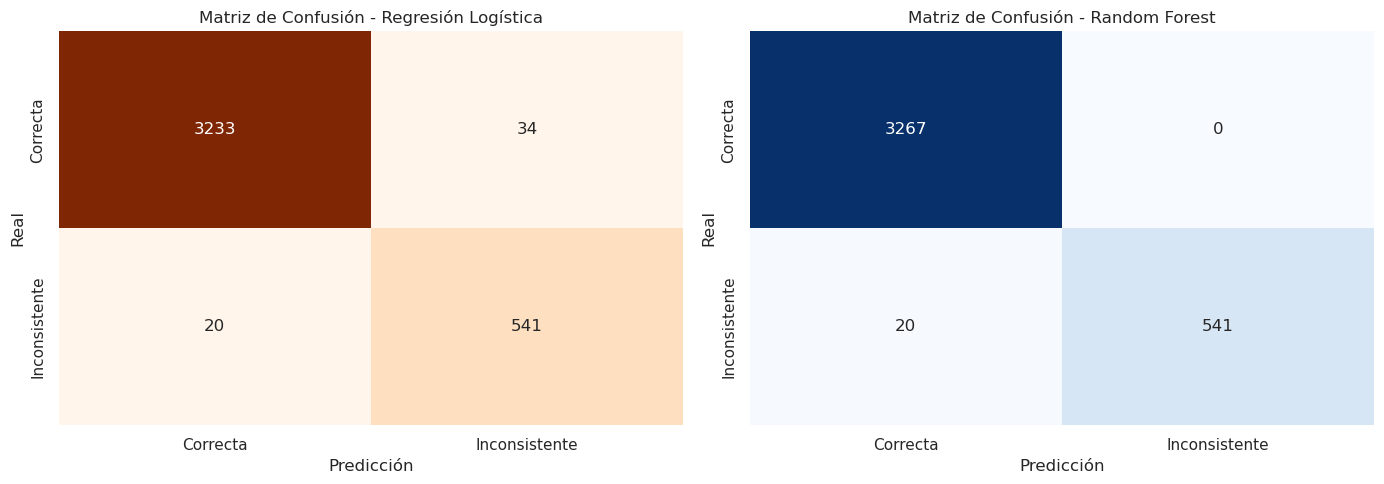

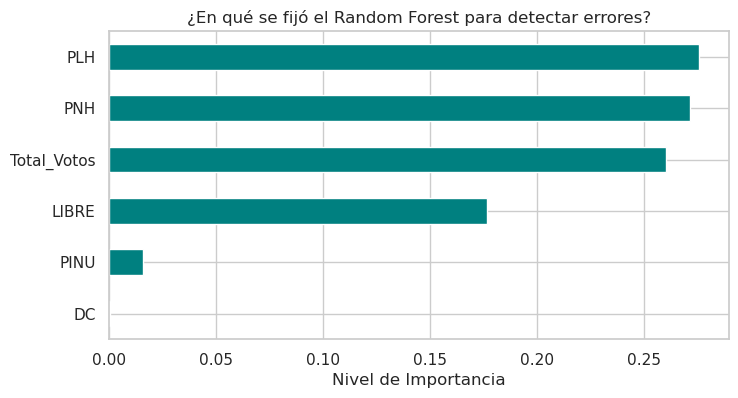

In [16]:
# ==========================================
# FASE I: EVALUACIÓN Y MÉTRICAS (Inciso d)
# ==========================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluar_modelo(modelo, X_test_data, nombre_modelo):
    y_pred = modelo.predict(X_test_data)

    # Extraemos métricas requeridas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"--- Rendimiento de: {nombre_modelo} ---")
    print(f"Exactitud (Accuracy) : {acc:.4f}")
    print(f"Precisión (Precision): {prec:.4f}")
    print(f"Sensibilidad (Recall): {rec:.4f}")
    print(f"F1-Score             : {f1:.4f}\n")

    return y_pred # Evaluación
pred_lr = evaluar_modelo(modelo_lr, X_test_scaled, "Regresión Logística")
pred_rf = evaluar_modelo(modelo_rf, X_test, "Random Forest")

# Graficar Matrices de Confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, pred_lr), annot=True, fmt='d', cmap='Oranges', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusión - Regresión Logística')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_xticklabels(['Correcta', 'Inconsistente'])
axes[0].set_yticklabels(['Correcta', 'Inconsistente'])

sns.heatmap(confusion_matrix(y_test, pred_rf), annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Confusión - Random Forest')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_xticklabels(['Correcta', 'Inconsistente'])
axes[1].set_yticklabels(['Correcta', 'Inconsistente'])

plt.tight_layout()
plt.show()

# Gráfico de Importancia de Variables (Por qué RF tomó la decisión)
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 4))
importancias.plot(kind='barh', color='teal')
plt.title('¿En qué se fijó el Random Forest para detectar errores?')
plt.xlabel('Nivel de Importancia')
plt.show()

In [17]:
# ==============================================================================
# PRUEBA DE ESTRÉS: PREDICCIÓN CON UNA NUEVA ACTA (CASO INCONSISTENTE)
# ==============================================================================

print("\n--- SIMULACIÓN DE AUDITORÍA EN TIEMPO REAL ---")

# 1. Creamos un acta con datos claramente alterados (Fraude/Error de digitación)
# Le pondremos números imposibles para una sola urna electoral.
votos_alterados = {
    'DC': [0],
    'LIBRE': [250],
    'PINU': [5],
    'PLH': [350],     # Un pico irreal
    'PNH': [400]      # Otro pico irreal
}

# 2. Convertimos a DataFrame para que el modelo lo entienda
acta_sospechosa = pd.DataFrame(votos_alterados)

# 3. Feature Engineering: Calculamos el Total de Votos de esta nueva acta
# El total será 1,005 votos (Físicamente imposible en una urna estándar)
acta_sospechosa['Total_Votos'] = acta_sospechosa.sum(axis=1)

# 4. Le pedimos a la IA que audite el acta a ciegas
# (Recuerda que estamos usando modelo_rf de la Fase 1)
prediccion = modelo_rf.predict(acta_sospechosa)

# 5. Mostramos el veredicto del modelo
print("Datos ingresados en el sistema:")
print(acta_sospechosa.to_string(index=False))
print("-" * 50)

if prediccion[0] == 1:
    print("🚨 ALERTA ROJA: El modelo de IA ha clasificado esta acta como INCONSISTENTE.")
    print("Motivo probable: El comportamiento de los partidos mayoritarios y la carga")
    print(f"electoral total ({acta_sospechosa['Total_Votos'].values[0]} votos) rompen los patrones matemáticos normales.")
else:
    print("✅ OK: El modelo predice que esta acta es CORRECTA.")


--- SIMULACIÓN DE AUDITORÍA EN TIEMPO REAL ---
Datos ingresados en el sistema:
 DC  LIBRE  PINU  PLH  PNH  Total_Votos
  0    250     5  350  400         1005
--------------------------------------------------
✅ OK: El modelo predice que esta acta es CORRECTA.


In [18]:
print("--- FASE II: AGRUPACIÓN POR CENTRO DE VOTACIÓN ---")

# 1. Agrupamos a nivel Centro (dentro de Departamento y Municipio)
df_centros = df_completo.groupby(['Departamento', 'Municipio', 'Centro']).agg(
    num_actas=('Acta Number', 'count'),
    total_votos=('Total_Votos', 'sum'),
    DC_mean=('DC', 'mean'),
    LIBRE_mean=('LIBRE', 'mean'),
    PINU_mean=('PINU', 'mean'),
    PLH_mean=('PLH', 'mean'),
    PNH_mean=('PNH', 'mean'),
    tasa_inconsistencia=('es_inconsistente', 'mean')
).reset_index()

--- FASE II: AGRUPACIÓN POR CENTRO DE VOTACIÓN ---


In [19]:
municipio_stats = df_centros.groupby(['Departamento', 'Municipio']).agg({
    'DC_mean':'mean', 'LIBRE_mean':'mean', 'PINU_mean':'mean',
    'PLH_mean':'mean', 'PNH_mean':'mean', 'total_votos':'mean'
}).add_suffix('_mun')

df_centros = df_centros.merge(municipio_stats, on=['Departamento', 'Municipio'], how='left')

# Desviaciones
for partido in ['DC', 'LIBRE', 'PINU', 'PLH', 'PNH']:
    df_centros[f'{partido}_dev'] = df_centros[f'{partido}_mean'] - df_centros[f'{partido}_mean_mun']

df_centros['total_votos_dev'] = df_centros['total_votos'] - df_centros['total_votos_mun']

print(f"Total de centros analizados: {df_centros.shape[0]}")
print(df_centros.head())

Total de centros analizados: 5762
  Departamento Municipio                                        Centro  \
0    ATLANTIDA   ARIZONA             001_ARIZONA - CEB GRACIAS A DIOS    
1    ATLANTIDA   ARIZONA  002_ATENAS DE SAN CRISTOBAL - CEB JUAN LINDO   
2    ATLANTIDA   ARIZONA            003_HICAQUE - CEB FROYLAN TURCIOS    
3    ATLANTIDA   ARIZONA      004_JILAMITO NUEVO - ESC. IBRAHIM GAMERO   
4    ATLANTIDA   ARIZONA      005_MEZAPA - ESC. ALFONSO GUILLEN ZELAYA   

   num_actas  total_votos   DC_mean  LIBRE_mean  PINU_mean    PLH_mean  \
0         14         2749  0.071429   27.500000   1.000000  109.714286   
1          5          925  0.200000   11.000000   0.800000   82.000000   
2          3          598  0.000000   20.666667   0.000000  103.666667   
3          2            0  0.000000    0.000000   0.000000    0.000000   
4          3          305  0.000000   11.333333   1.333333   54.000000   

    PNH_mean  ...  PINU_mean_mun  PLH_mean_mun  PNH_mean_mun  total_votos_mu

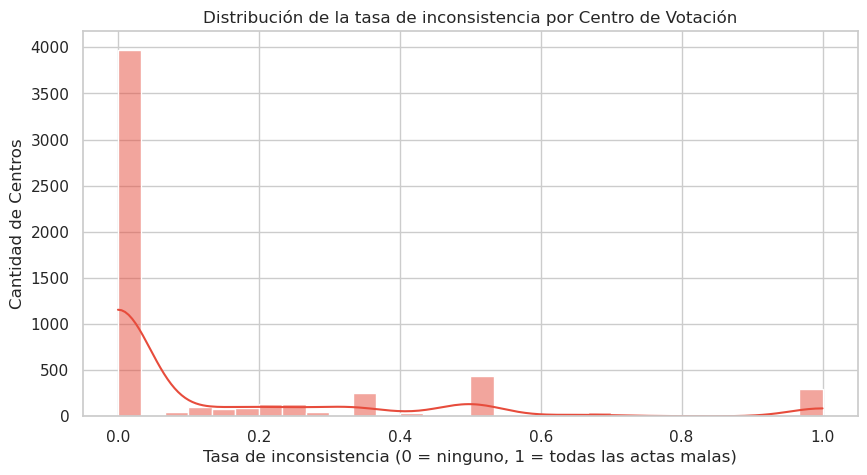

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(df_centros['tasa_inconsistencia'], bins=30, kde=True, color='#e74c3c')
plt.title('Distribución de la tasa de inconsistencia por Centro de Votación')
plt.xlabel('Tasa de inconsistencia (0 = ninguno, 1 = todas las actas malas)')
plt.ylabel('Cantidad de Centros')
plt.show()

In [24]:

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Detección de atípicos
features = ['DC_dev', 'LIBRE_dev', 'PINU_dev', 'PLH_dev', 'PNH_dev',
            'total_votos_dev', 'num_actas', 'tasa_inconsistencia']

X = df_centros[features].fillna(0)

# Escalamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modelo
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_centros['anomaly_score'] = iso_forest.fit_predict(X_scaled)
df_centros['es_anomalo'] = df_centros['anomaly_score'].map({-1: 1, 1: 0})

print(f"Centros detectados como ANÓMALOS: {df_centros['es_anomalo'].sum()} de {df_centros.shape[0]}")

Centros detectados como ANÓMALOS: 289 de 5762


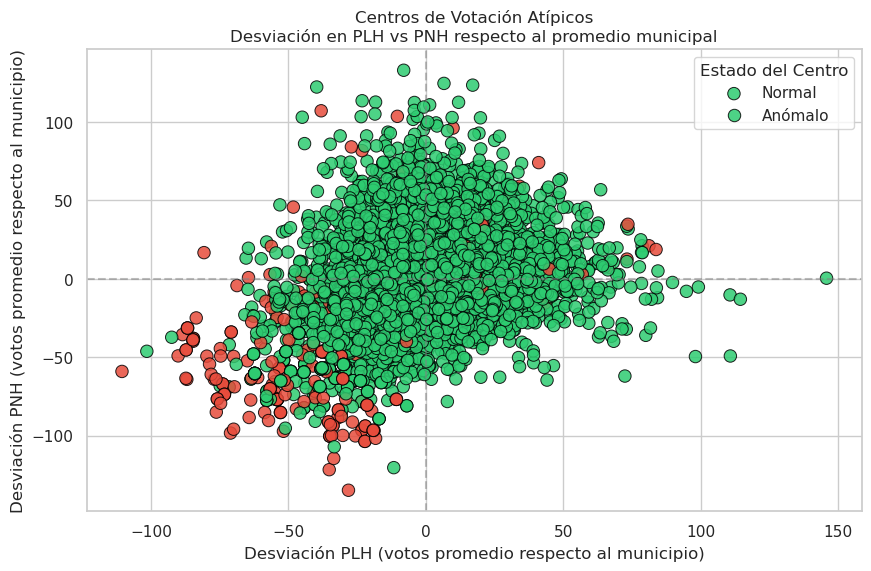

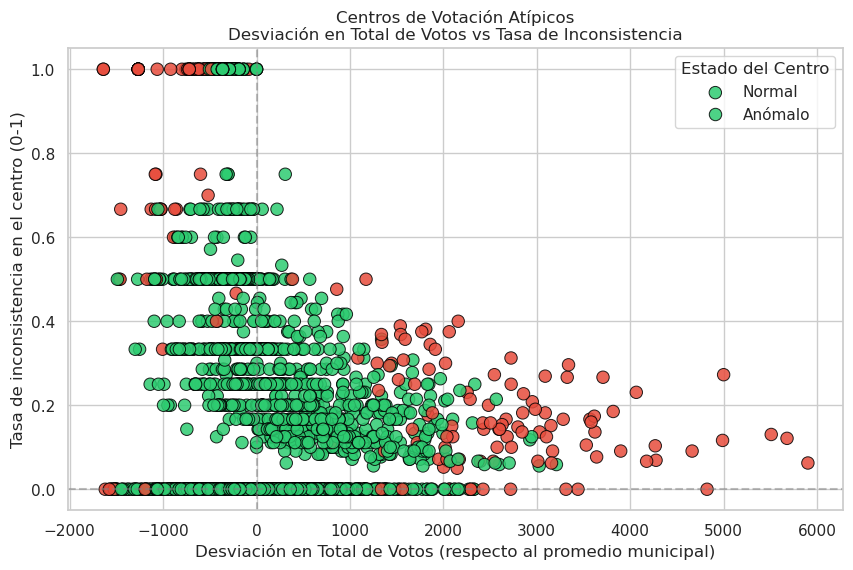

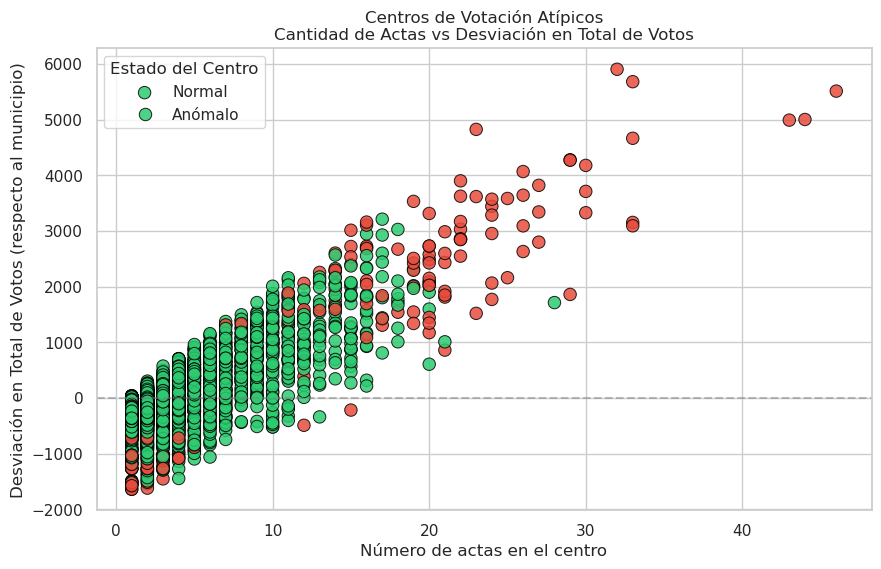

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
palette = {0: '#2ecc71', 1: '#e74c3c'}   # Normal = verde, Anómalo = rojo

# Gráfico 1: Desviaciones PLH vs PNH
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_centros,
    x='PLH_dev',
    y='PNH_dev',
    hue='es_anomalo',
    palette=palette,
    s=80, alpha=0.85,
    edgecolor='black'
)
plt.title('Centros de Votación Atípicos\nDesviación en PLH vs PNH respecto al promedio municipal')
plt.xlabel('Desviación PLH (votos promedio respecto al municipio)')
plt.ylabel('Desviación PNH (votos promedio respecto al municipio)')
plt.legend(title='Estado del Centro', labels=['Normal', 'Anómalo'])
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.show()

# Gráfico 2: Volumen total vs Tasa de inconsistencia
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_centros,
    x='total_votos_dev',
    y='tasa_inconsistencia',
    hue='es_anomalo',
    palette=palette,
    s=80, alpha=0.85,
    edgecolor='black'
)
plt.title('Centros de Votación Atípicos\nDesviación en Total de Votos vs Tasa de Inconsistencia')
plt.xlabel('Desviación en Total de Votos (respecto al promedio municipal)')
plt.ylabel('Tasa de inconsistencia en el centro (0-1)')
plt.legend(title='Estado del Centro', labels=['Normal', 'Anómalo'])
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.show()

# Gráfico 3: Total de actas vs Desviación en votos totales (detecta urnas "infladas"
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_centros,
    x='num_actas',
    y='total_votos_dev',
    hue='es_anomalo',
    palette=palette,
    s=80, alpha=0.85,
    edgecolor='black'
)
plt.title('Centros de Votación Atípicos\nCantidad de Actas vs Desviación en Total de Votos')
plt.xlabel('Número de actas en el centro')
plt.ylabel('Desviación en Total de Votos (respecto al municipio)')
plt.legend(title='Estado del Centro', labels=['Normal', 'Anómalo'])
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.show()

In [26]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)
df_centros['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
df_centros['es_anomalo_dbscan'] = (df_centros['dbscan_cluster'] == -1).astype(int)

print("Centros marcados como anomalías por DBSCAN:", df_centros['es_anomalo_dbscan'].sum())

Centros marcados como anomalías por DBSCAN: 1815


In [27]:
# ANÁLISIS DE CENTROS ANÓMALOS QUE NO ESTABAN MARCADOS COMO INCONSISTENTES

centros_anomalos = df_centros[df_centros['es_anomalo'] == 1].copy()

# Unión de actas originales, para ver las actas individuales
actas_anomalas = df_completo.merge(
    centros_anomalos[['Departamento', 'Municipio', 'Centro', 'es_anomalo', 'tasa_inconsistencia']],
    on=['Departamento', 'Municipio', 'Centro'],
    how='inner'
)

# Actas no marcadas como inconsistentes pero están como anómalas
actas_ocultas = actas_anomalas[(actas_anomalas['es_inconsistente'] == 0) &
                               (actas_anomalas['es_anomalo'] == 1)]

print(f"¡ALERTA! Actas con comportamiento anómalo pero NO marcadas por el CNE: {len(actas_ocultas)}")
print(actas_ocultas[['Departamento', 'Municipio', 'Centro', 'Total_Votos',
                     'PLH', 'PNH', 'tasa_inconsistencia']].head(10))

¡ALERTA! Actas con comportamiento anómalo pero NO marcadas por el CNE: 1891
  Departamento Municipio                                       Centro  \
0    ATLANTIDA  LA CEIBA  033_COL. PIZATTY - INST. JUAN PINEDA CARIAS   
1    ATLANTIDA  LA CEIBA  033_COL. PIZATTY - INST. JUAN PINEDA CARIAS   
2    ATLANTIDA  LA CEIBA  033_COL. PIZATTY - INST. JUAN PINEDA CARIAS   
3    ATLANTIDA  LA CEIBA  033_COL. PIZATTY - INST. JUAN PINEDA CARIAS   
4    ATLANTIDA  LA CEIBA  033_COL. PIZATTY - INST. JUAN PINEDA CARIAS   
5    ATLANTIDA  LA CEIBA  033_COL. PIZATTY - INST. JUAN PINEDA CARIAS   
6    ATLANTIDA  LA CEIBA  033_COL. PIZATTY - INST. JUAN PINEDA CARIAS   
7    ATLANTIDA  LA CEIBA  033_COL. PIZATTY - INST. JUAN PINEDA CARIAS   
8    ATLANTIDA  LA CEIBA  033_COL. PIZATTY - INST. JUAN PINEDA CARIAS   
9    ATLANTIDA  LA CEIBA  033_COL. PIZATTY - INST. JUAN PINEDA CARIAS   

   Total_Votos  PLH  PNH  tasa_inconsistencia  
0          187  115   41                  0.0  
1          199  123   45

In [28]:
#Agrupacion de los datos por departamento y municipio

print("--- AGRUPACIÓN POR DEPARTAMENTO Y MUNICIPIO ---")

df_regiones = df_completo.groupby(['Departamento', 'Municipio']).agg(
    total_actas=('Acta Number', 'count'),
    actas_inconsistentes=('es_inconsistente', 'sum')
).reset_index()

print(df_regiones.head())

--- AGRUPACIÓN POR DEPARTAMENTO Y MUNICIPIO ---
  Departamento    Municipio  total_actas  actas_inconsistentes
0    ATLANTIDA      ARIZONA           62                    10
1    ATLANTIDA  EL PORVENIR           49                     9
2    ATLANTIDA      ESPARTA           45                     5
3    ATLANTIDA      JUTIAPA           85                     3
4    ATLANTIDA     LA CEIBA          363                    42


In [29]:
#calcular la taza de de inconsistencia regional

df_regiones['tasa_inconsistencia'] = (
    df_regiones['actas_inconsistentes'] / df_regiones['total_actas']
)

print(df_regiones.sort_values(by='tasa_inconsistencia', ascending=False).head(10))

            Departamento      Municipio  total_actas  actas_inconsistentes  \
289  VOTO EN EL EXTERIOR      CHARLOTTE            1                     1   
298  VOTO EN EL EXTERIOR     WASHINGTON            2                     2   
297  VOTO EN EL EXTERIOR  SAN FRANCISCO            1                     1   
296  VOTO EN EL EXTERIOR       NEW YORK            1                     1   
294  VOTO EN EL EXTERIOR          MIAMI            2                     1   
292  VOTO EN EL EXTERIOR        HOUSTON            2                     1   
209              LEMPIRA     VALLADOLID           11                     5   
271        SANTA BARBARA     SAN MARCOS           37                    16   
135    FRANCISCO MORAZAN    VALLECILLOS           20                     8   
163    ISLAS DE LA BAHIA          UTILA           10                     4   

     tasa_inconsistencia  
289             1.000000  
298             1.000000  
297             1.000000  
296             1.000000  
294   

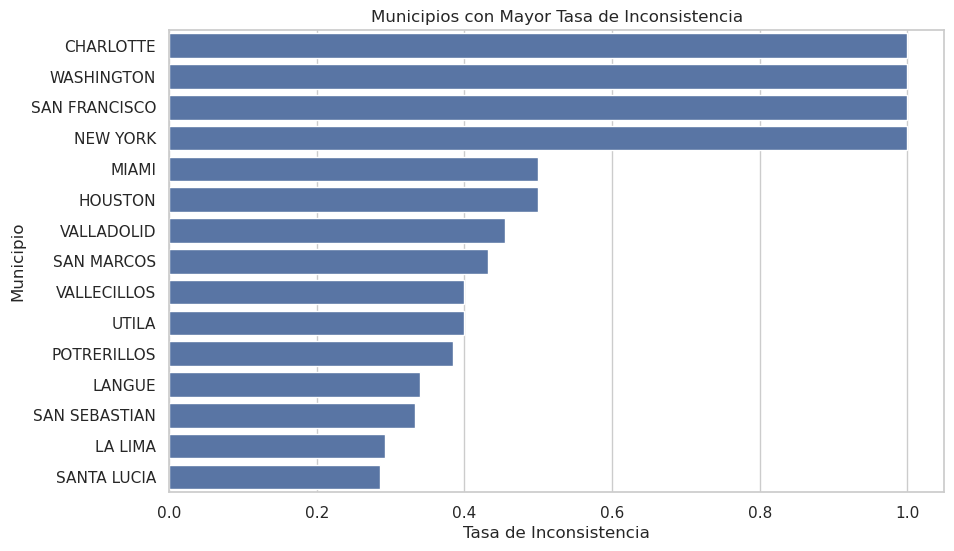

In [30]:
municipios = df_regiones.sort_values(by='tasa_inconsistencia', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(
    data=municipios,
    y='Municipio',
    x='tasa_inconsistencia'
)

plt.title('Municipios con Mayor Tasa de Inconsistencia')
plt.xlabel('Tasa de Inconsistencia')
plt.ylabel('Municipio')
plt.show()

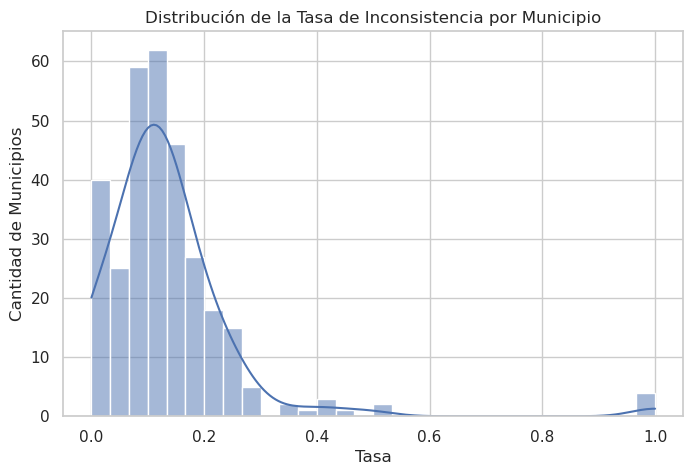

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df_regiones['tasa_inconsistencia'], bins=30, kde=True)

plt.title('Distribución de la Tasa de Inconsistencia por Municipio')
plt.xlabel('Tasa')
plt.ylabel('Cantidad de Municipios')
plt.show()

In [32]:
df_departamento = df_completo.groupby('Departamento').agg(
    total_actas=('Acta Number', 'count'),
    actas_inconsistentes=('es_inconsistente', 'sum')
).reset_index()

df_departamento['tasa_inconsistencia'] = (
    df_departamento['actas_inconsistentes'] / df_departamento['total_actas']
)

print(df_departamento.sort_values(by='tasa_inconsistencia', ascending=False))

           Departamento  total_actas  actas_inconsistentes  \
17  VOTO EN EL EXTERIOR           15                     7   
7     FRANCISCO MORAZAN         3400                   682   
8        GRACIAS A DIOS          177                    34   
10    ISLAS DE LA BAHIA          155                    29   
18                 YORO         1286                   215   
11               LA PAZ          491                    80   
5                CORTES         3324                   512   
3             COMAYAGUA         1139                   164   
15        SANTA BARBARA         1094                   152   
16                VALLE          458                    63   
6            EL PARAISO         1095                   148   
2                 COLON          684                    90   
9              INTIBUCA          570                    73   
0             ATLANTIDA          939                   108   
1             CHOLUTECA         1100                   126   
4       

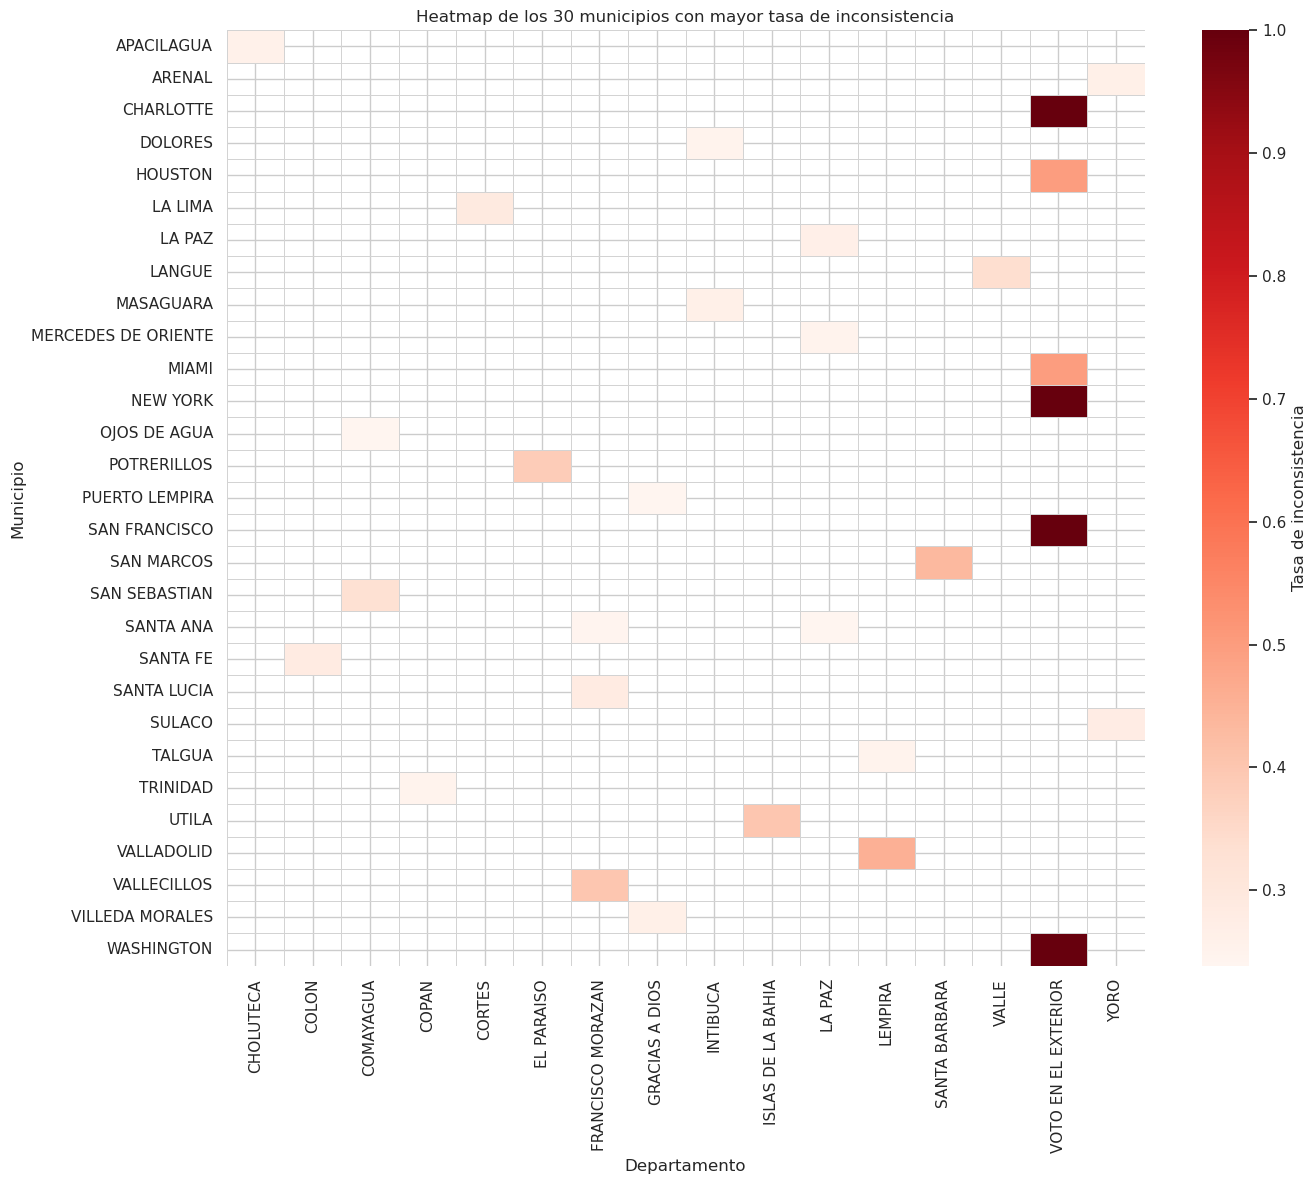

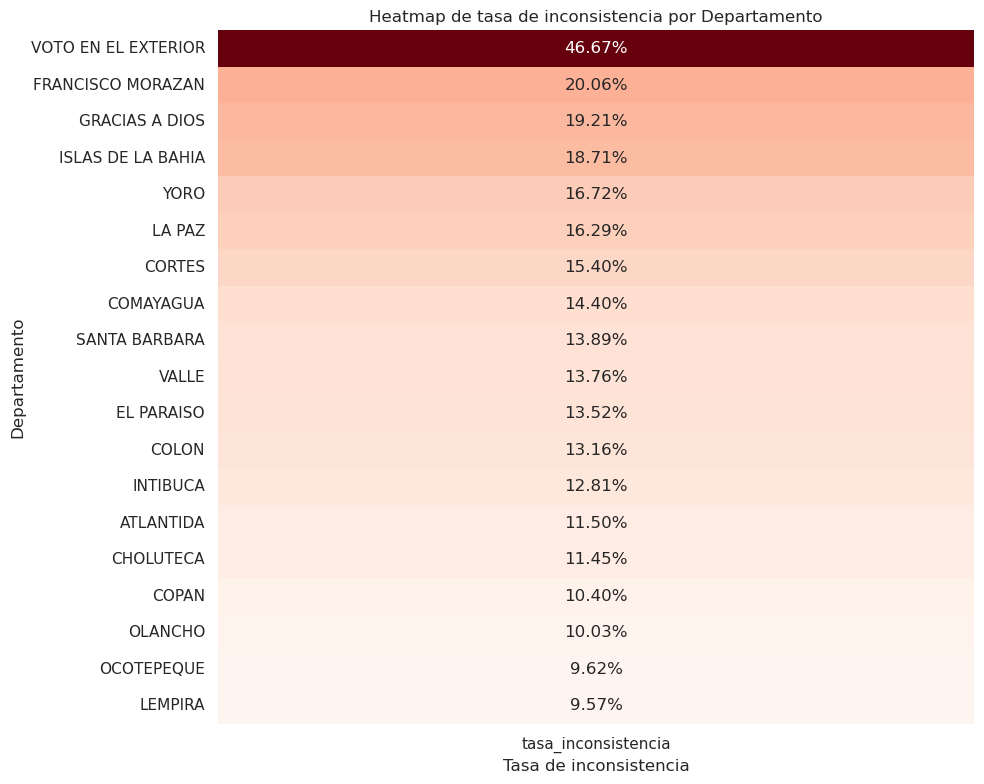

In [33]:
#c.
# Visualizar la intensidad de inconsistencia mediante mapas de calor

df_top_municipios = df_regiones.sort_values(by='tasa_inconsistencia', ascending=False).head(30)
pivot_top = df_top_municipios.pivot(index='Municipio', columns='Departamento', values='tasa_inconsistencia')

plt.figure(figsize=(14,12))
sns.heatmap(
    pivot_top,
    cmap='Reds',
    linewidths=0.4,
    linecolor='lightgray',
    cbar_kws={'label': 'Tasa de inconsistencia'}
)
plt.title('Heatmap de los 30 municipios con mayor tasa de inconsistencia')
plt.xlabel('Departamento')
plt.ylabel('Municipio')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(
    df_departamento.set_index('Departamento')[['tasa_inconsistencia']].sort_values(by='tasa_inconsistencia', ascending=False),
    annot=True,
    fmt='.2%',
    cmap='Reds',
    cbar=False
)
plt.title('Heatmap de tasa de inconsistencia por Departamento')
plt.xlabel('Tasa de inconsistencia')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()


In [ ]:
### c. Mapas de calor de inconsistencia
En el heatmap se representan las tasas de inconsistencia por municipio y por departamento. Los municipios con mayor tasa de inconsistencia quedan claramente concentrados en zonas específicas, lo que ayuda a visualizar un patrón de vecindad geográfica.

### d. Conclusión sobre distribución geográfica
Los errores no parecen distribuirse de forma completamente aleatoria. La visualización muestra que algunas zonas, especialmente ciertos municipios y departamentos del extranjero, concentran tasas más altas de inconsistencia. Por lo tanto, existe evidencia de un comportamiento de clústeres geográficos en lugar de errores aislados distribuidos uniformemente en todo el territorio.